<a href="https://colab.research.google.com/github/olucasaguiar/estudos-sobre-machine-learning/blob/main/temas/natural-language-processing/DeepLearning-lucas_nascimento_aguiar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing com Deep Learning

O propósito deste Notebook é utilizar conhecimentos de Deep Learning para classificar frases sintéticas (geradas por um LLM) em uma dimensão binária que determine um sentimento, positivo ou negativo. A tarefa de classificação descrita é conhecida por "análise de sentimentos".

O resultado do modelo com rede neural será comparado com os dados sintéticos através da comparação entre o target esperado e o executado pelo modelo.

## Metodologia

### Preparação dos dados

O carregamento dos dados será feito através do Kaggle Hub para continuar o uso do dataset do trabalho anterior. O dataset utilizado é proveniente do projeto **Opinando**, o *UTLCorpus*. Este dataset possui mais de 2 milhões de resenhas de filmes coletadas do Filmow, uma popular rede social de filmes, e foi tratado especificamente como UTLC-Movies neste contexto, com todas as avaliações que possuíam classificação 0 removidas para garantir a qualidade dos dados.

Os dados do dataset serão preparados de forma simples, será selecionado do conjunto de 10.000 amostras as colunas "review_text" e "polarity". Sendo que, para balancear as amostras, metade dos dados do conjunto será de resenhas positivas (`polarity == 1`) e a outra metade de resenhas negativas (`polarity == 0`).

Do conjunto total dos dados, 9.000 amostras serão utilizadas para treinamento (4.500 resenhas positivas e 4.500 resenhas negativas) e apenas 1000 serão utilizadas para teste (500 resenhas positivas e 500 resenhas negativas).

In [1]:
"""
Carregando o dataset de análise de sentimentos em português do Kaggle.
O dataset contém resenhas de filmes, com a respectiva polaridade (1 para positivo e 0 para negativo) e a classificação (de 1 a 5 estrelas).
Para acelerar o treinamento do modelo, diminui o tamanho do dataset para 10.000 amostras, garantindo a mesma proporção de classes positivas e negativas.
"""
%pip install ipywidgets kagglehub pandas numpy -q
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter


dataset_handle = "fredericods/ptbr-sentiment-analysis-datasets"
dataset_file = "utlc_movies.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_handle,
    dataset_file,
)
df = df[["review_text", "polarity"]]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.8 MB/s eta 0:00:00


100%|██████████| 318M/318M [00:08<00:00, 37.2MB/s]

Extracting zip of utlc_movies.csv...


In [2]:
print(df.info(), df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487449 entries, 0 to 1487448
Data columns (total 2 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   review_text  1487449 non-null  object 
 1   polarity     1189542 non-null  float64
dtypes: float64(1), object(1)
memory usage: 22.7+ MB
None                                          review_text  polarity
0                         Um dos melhores desenhos!!       1.0
1  O filme é realmente diferente e bem lento mas ...       1.0
2     Hilário em alguns momentos, e muito bem feito.       1.0
3                         choro toda vez que vejo :(       1.0
4                                           Niiiice!       1.0


In [3]:
import pandas as pd

N_SAMPLES = 10_000

TRAIN_SIZE = 9_000
TEST_SIZE = N_SAMPLES - TRAIN_SIZE

positive_samples = df[df["polarity"] == 1].sample(
    n=(N_SAMPLES // 2),
    random_state=42,
)
negative_samples = df[df["polarity"] == 0].sample(
    n=(N_SAMPLES // 2),
    random_state=42,
)

train_df = (
    pd.concat(
        [positive_samples[: TRAIN_SIZE // 2], negative_samples[: TRAIN_SIZE // 2]],
    )
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
test_df = (
    pd.concat(
        [positive_samples[TRAIN_SIZE // 2 :], negative_samples[TRAIN_SIZE // 2 :]],
    )
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

X_train, y_train, X_test, y_test = (
    train_df["review_text"],
    train_df["polarity"],
    test_df["review_text"],
    test_df["polarity"],
)

print("Tamanho do conjunto de treinamento:", len(X_train))
print("Tamanho do conjunto de teste:", len(X_test))

Tamanho do conjunto de treinamento: 9000
Tamanho do conjunto de teste: 1000


### Embedding Pre-Trained Model

Como o objetivo deste Python Notebook é realizar o treinamento de um modelo para análise de sentimentos utilizando aprendizado profundo, o modelo de embedding será carregado a partir de um modelo treinado previamente e disponibilizado no catalogo da *Hugging Face*.

Iremos utilizar o modelo da família *SBERT* conhecido como *paraphrase-multilingual-MiniLM-L12-v2* que possui suporte para o idioma Português e é treinado para a tarefa de embedding. O carregamento do modelo será feito utilizando a biblioteca `sentence_transformers`.

In [4]:
%pip install sentence-transformers -q
import torch
from sentence_transformers import SentenceTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embedding_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', backend='torch', device=device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Treinamento do modelo

O processo de treinamento do modelo envolve primeiramente a **Geração de Embeddings**, onde os textos das resenhas são transformados em representações numéricas por meio do modelo pré-treinado *paraphrase-multilingual-MiniLM-L12-v2* do SBERT, capturando o significado semântico. Em seguida, ocorre a **Preparação dos Dados para Treinamento**, organizando esses embeddings e seus rótulos de polaridade (0 ou 1) em `TensorDataset` e `DataLoader` para processamento em lotes.

Para a **Definição do Modelo Classificador**, um `Multilayer Perceptron (MLP)` simples é construído para receber os embeddings e classificar o sentimento. A **Configuração de Perda e Otimizador** utiliza `CrossEntropyLoss` e `Adam` para guiar o aprendizado.

O **Ciclo de Treinamento** adotado consiste em um número definido de épocas, onde o modelo é treinado, os dados são processados em lotes para calcular a perda, retropropagar gradientes e atualizar os pesos. Finalmente, a **Avaliação** é realizada após cada época, com o modelo em modo de avaliação, para monitorar o desempenho no conjunto de teste, utilizando métricas como perda e acurácia.

In [5]:
import torch
from torch import nn
from torch.accelerator import current_accelerator, is_available


# Definindo um modelo simples de Multilayer Perceptron (MLP) para classificação de sentimentos
class MLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 5),
        )

    def forward(self, x) -> torch.Tensor:
        return self.net(x)


device = current_accelerator().type if is_available() else "cpu"

# Criando o modelo utilizando a dimensão de embedding do modelo pré-treinado como entrada
classifier_model = MLP(input_dim=embedding_model.get_sentence_embedding_dimension()).to(
    device
)

# Definindo a função de perda e o otimizador para treinamento do modelo de classificação
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier_model.parameters())

In [6]:
import torch
from torch import nn
from torch.optim import Optimizer
from torch.utils.data import DataLoader

# type aliases
Loss = float
Accuracy = float


def train(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: Optimizer,
    criterion: nn.Module,
) -> Loss:
    model.train()
    total_loss = 0
    for batch in dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)


def evaluate(
    model: nn.Module, dataloader: DataLoader, criterion: nn.Module
) -> tuple[Loss, Accuracy]:
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
    accuracy = correct / len(dataloader.dataset)
    return total_loss / len(dataloader), accuracy

In [7]:
from torch.utils.data import TensorDataset, DataLoader

# Convertendo os textos de treinamento e teste em embeddings utilizando o modelo pré-treinado
train_dataset = TensorDataset(
    embedding_model.encode(X_train.tolist(), convert_to_tensor=True),
    torch.tensor(y_train.values, dtype=torch.long),
)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(
    embedding_model.encode(X_test.tolist(), convert_to_tensor=True),
    torch.tensor(y_test.values, dtype=torch.long),
)
test_dataloader = DataLoader(test_dataset, batch_size=32)

# Treinando o modelo por 5 épocas
EPOCHS = 5
for epoch in range(EPOCHS):
    train_loss = train(classifier_model, train_dataloader, optimizer, criterion)
    test_loss, test_accuracy = evaluate(classifier_model, test_dataloader, criterion)
    print(
        f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f} - Test Loss: {test_loss:.4f} - Test Accuracy: {test_accuracy:.4f}"
    )

Epoch 1/5 - Train Loss: 0.6091 - Test Loss: 0.4953 - Test Accuracy: 0.7670
Epoch 2/5 - Train Loss: 0.4819 - Test Loss: 0.4958 - Test Accuracy: 0.7640
Epoch 3/5 - Train Loss: 0.4690 - Test Loss: 0.4848 - Test Accuracy: 0.7630
Epoch 4/5 - Train Loss: 0.4546 - Test Loss: 0.4793 - Test Accuracy: 0.7720
Epoch 5/5 - Train Loss: 0.4367 - Test Loss: 0.4811 - Test Accuracy: 0.7680


## Análise de Resultados

Os resultados do modelo foram avaliados em dois conjuntos de dados distintos: o conjunto de teste, composto por amostras reais do dataset original, e um conjunto de dados simulados, gerado artificialmente para testar a capacidade de generalização em cenários ideais.

In [8]:
%pip install seaborn matplotlib -q
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from torch import nn
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(y_true: list, y_pred: list, title: str) -> None:
    cv = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cv, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

def predict(model: nn.Module, texts: list) -> list:
    model.eval()
    with torch.no_grad():
        embeddings = embedding_model.encode(texts, convert_to_tensor=True).to(device)
        outputs = model(embeddings)
        _, predicted = torch.max(outputs, 1)
    return predicted.cpu().numpy()

### Desempenho no Conjunto de Teste

No conjunto de teste, o modelo obteve uma acurácia geral de **77%**. Detalhando o relatório de classificação:

*   Para a classe `0.0` (sentimento negativo):
    *   **Precisão**: 0.74 (74% das previsões negativas estavam corretas)
    *   **Recall**: 0.84 (84% das amostras negativas reais foram corretamente identificadas)
    *   **F1-score**: 0.78
*   Para a classe `1.0` (sentimento positivo):
    *   **Precisão**: 0.81 (81% das previsões positivas estavam corretas)
    *   **Recall**: 0.70 (70% das amostras positivas reais foram corretamente identificadas)
    *   **F1-score**: 0.75

A matriz de confusão para o conjunto de teste visualiza esses números, mostrando uma distribuição razoavelmente equilibrada entre os erros de classificação, com o modelo conseguindo identificar a maioria dos sentimentos corretamente, embora com alguma dificuldade em diferenciar entre falsos positivos e falsos negativos de forma consistente para ambas as classes.

Relatório de Classificação - Test Data
              precision    recall  f1-score   support

         0.0       0.74      0.84      0.78       500
         1.0       0.81      0.70      0.75       500

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



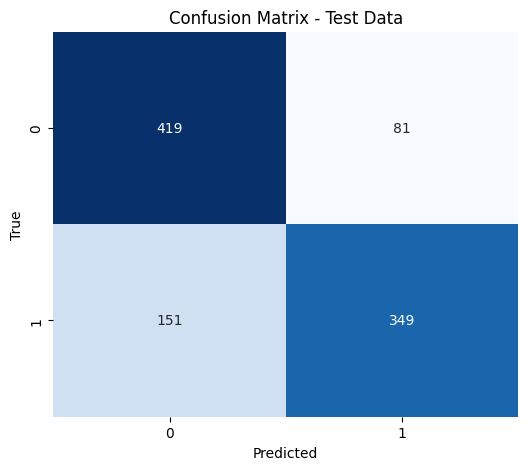

In [9]:
import pandas as pd
from sklearn.metrics import classification_report

# Avaliação do modelo em dados de teste
y_true = y_test.values
y_pred = predict(classifier_model, X_test.tolist())

print("Relatório de Classificação - Test Data")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred, "Confusion Matrix - Test Data")

### Desempenho no Conjunto de Dados Simulados

Em contraste, o modelo demonstrou um desempenho significativamente superior no conjunto de dados simulados, atingindo uma acurácia notável de **92%**. O relatório de classificação revela:

*   Para a classe `0` (sentimento negativo):
    *   **Precisão**: 0.88
    *   **Recall**: 0.98
    *   **F1-score**: 0.92
*   Para a classe `1` (sentimento positivo):
    *   **Precisão**: 0.98
    *   **Recall**: 0.86
    *   **F1-score**: 0.91

A matriz de confusão para os dados simulados apresenta um número muito menor de classificações incorretas, indicando que o modelo foi altamente eficaz na categorização das resenhas sintéticas. Isso sugere que os dados simulados podem ter características mais distintas e menos ambíguas, facilitando a tarefa de classificação para o modelo.

Relatório de Classificação - Simulated Data
              precision    recall  f1-score   support

           0       0.88      0.98      0.92        50
           1       0.98      0.86      0.91        50

    accuracy                           0.92       100
   macro avg       0.93      0.92      0.92       100
weighted avg       0.93      0.92      0.92       100



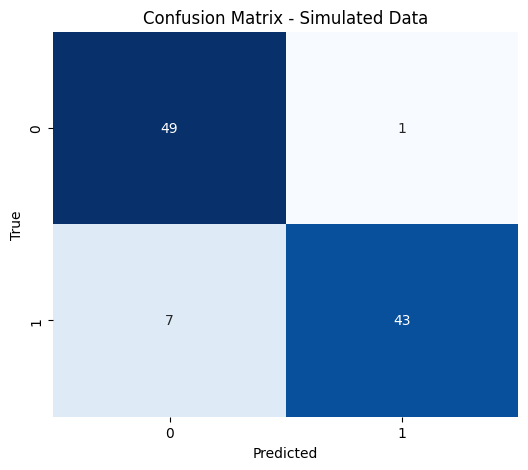

In [11]:
import pandas as pd
from sklearn.metrics import classification_report

# Avaliação do modelo em dados simulados
simulated_texts = pd.read_csv("https://github.com/olucasaguiar/estudos-sobre-machine-learning/raw/main/temas/natural-language-processing/simulated_reviews.csv")
y_true = simulated_texts["polarity"].values
y_pred = predict(classifier_model, simulated_texts["review_text"].tolist())

print("Relatório de Classificação - Simulated Data")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred, "Confusion Matrix - Simulated Data")

### Comparação e Discussão

A diferença no desempenho entre os dois conjuntos é marcante. Enquanto a acurácia de 77% no conjunto de teste é razoável para uma tarefa de análise de sentimentos em português, o desempenho de 92% nos dados simulados destaca que o modelo pode ser muito eficaz em dados que se alinham perfeitamente com os padrões que ele aprendeu. Essa discrepância pode ser atribuída a vários fatores:

1.  **Complexidade dos Dados Reais vs. Simulados**: Os dados de teste, provenientes de resenhas reais, tendem a ter maior variação linguística, sarcasmo, gírias, erros de português e nuances que tornam a classificação mais desafiadora. Os dados simulados, por serem gerados, podem ter sido construídos com uma linguagem mais direta e sentimentos mais explícitos, facilitando a identificação.
2.  **Generalização**: O modelo demonstra boa capacidade de generalização para cenários mais controlados e ideais (dados simulados), mas enfrenta desafios maiores quando exposto à imprevisibilidade e sutileza da linguagem natural em um contexto real. O conjunto de dados simulados pode não capturar toda a complexidade e variabilidade das resenhas de filmes do mundo real.

Em resumo, o modelo tem um desempenho sólido em dados de teste realistas, mas brilha em dados simulados. Isso sugere que, para aplicações práticas, é importante considerar a robustez do modelo frente à variedade e complexidade da linguagem natural, e que a geração de dados sintéticos deve tentar refletir ao máximo a realidade para ser uma métrica de avaliação mais confiável.